#LAB 1: VGGNet & ResNet

<h4><div style="text-align: right"> Due date: 15:00 Oct 02, 2025.  </div> <br>
<div style="text-align: right"> Please upload your file and final-report at PLATO before the class in the form of [ID_Name_Lab1.ipynb]. </div></h4>

### *Instructions:*
- Write a program implementing a particular algorithm to solve a given problem.   
- <span style="color:red">**Report and discuss your results. Analyze the algorithm, theoretically and empirically.**</span>
- You must write their own answers and codes (<span style="color:red">**if not you will get a F grade**</span>).

<h2><span style="color:blue">[202355532] [THADAR SOE]</span> </h2>


In [1]:
import datetime
print("This code is written at " + str(datetime.datetime.now()))

This code is written at 2025-10-09 15:38:38.114036


In [20]:
#####################################################################
# In order to use GPU acceleration, you must change runtime type.
# See the menu bar above.
# "Runtime" -> "Change runtime type"  -> "Hardware accelerator"
# Change 'None' to 'GPU', then run the code below.
#####################################################################

import sys
import platform
import torch

print("Python version")
print(sys.version_info)

print("\nOS information")
print(platform.platform())

print("\nIs GPU available?")
print(torch.cuda.is_available())

# print("\nCPU information")
# !cat /proc/cpuinfo

# print("\nMemory information")
# !cat /proc/meminfo

print("\nGPU information")
!nvidia-smi

Python version
sys.version_info(major=3, minor=12, micro=11, releaselevel='final', serial=0)

OS information
Linux-6.6.97+-x86_64-with-glibc2.35

Is GPU available?
True

GPU information
Fri Oct 10 04:02:10 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             37W /   70W |   

## 1. VGGNet with PyTorch

### Implementing VGGNet

1. **Dataset**
 - Images from the first three categories in CIFAR-10. (Due to the computational constraints.)  <br>
     Three categories : plane, car, bird  /  The number of training images : 15,000   /  The number of test images : 3,000
 - Augmented with flipping and random cropping.

 2. **Network architecture**
 - Type-D configuration in the paper (+ 3-way classifier after convolutional layers).
 - ReLU activation.
 - No dropout for simplicity.
 - We will apply **batch-normalization** after every convolution which is not used in the paper (otherwise, hard to optimize).

 <table><tr>
 <td> <img src="https://docs.google.com/uc?export=download&id=1WoLTNYR11nbIE7ovpaum2DN_u71zow6r" alt="no_image" style="width: 550px;"/> </td>
 </tr></table>

 <font size="0.5"> Figure from <br>
 [1] https://www.quora.com/What-is-the-VGG-neural-network </font>

3. **Loss function**
 - Cross-entropy loss between outputs & ground-truths. <br>
     Note that `nn.CrossEntroyLoss` takes logits before softmax as network outputs and scalar index (not one-hot vector) as ground-truths.<br>
     See https://pytorch.org/docs/stable/nn.html#crossentropyloss for details.

 4. **Training**
 - Default weight initialization for simplicity.
 - SGD optimizer with `learning rate = 1e-2`, `momentum = 0.9`, and `weight_decay = 5e-4`.
 - 20 epochs without learning rate scheduling.

 5. **Evaluation metric**
 - Classification accuracy (i.e., the percentage of correct predictions).

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import torchvision
import time
import os

# os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [22]:
print('STEP 1: LOADING DATASET')

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(), #RandomCrop only augmentation done by commenting out this line
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = dsets.CIFAR10(root='./data/CIFAR10/',
                            train=True,
                            transform=transform_train,
                            download=True)

test_dataset = dsets.CIFAR10(root='./data/CIFAR10/',
                           train=False,
                           transform=transform_test)

STEP 1: LOADING DATASET


In [23]:
# reducing the dataset
reduced_train_dataset = []
for images, labels in train_dataset:
    if labels < 3:
        reduced_train_dataset.append((images, labels))

reduced_test_dataset = []
for images, labels in test_dataset:
    if labels < 3:
        reduced_test_dataset.append((images, labels))

In [24]:
print("The number of training images : ", len(reduced_train_dataset))
print("The number of test images : ", len(reduced_test_dataset))

The number of training images :  15000
The number of test images :  3000


In [25]:
print('STEP 2: MAKING DATASET ITERABLE')

train_loader = torch.utils.data.DataLoader(dataset=reduced_train_dataset,
                                           batch_size=128,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=reduced_test_dataset,
                                          batch_size=100,
                                          shuffle=False)

class_names = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

STEP 2: MAKING DATASET ITERABLE


### Visualize a few images

In [26]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [27]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

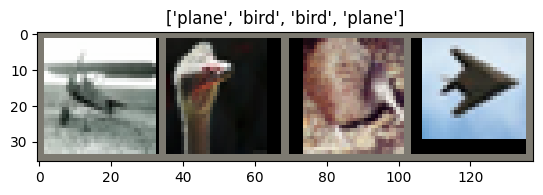

In [28]:
train_loader_sample = torch.utils.data.DataLoader(dataset=reduced_train_dataset,
                                           batch_size=4,
                                           shuffle=True)

# Get a batch of training data
inputs, classes = next(iter(train_loader_sample))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

### 1.1 Write code (VGG 16) [3 points]

In [29]:
print('STEP 3: CREATE MODEL CLASS (VGG16)')

import torch
import torch.nn as nn

cfg = [64, 64, 'MP', 128, 128, 128, 'MP', 512, 512, 512, 'MP', 512, 512, 512, 'MP']

class VGG(nn.Module):
    def __init__(self):
        super(VGG, self).__init__()
        self.VGG16 = self._make_layers(cfg)
        self.classifier = nn.Linear(512, 3)

    def forward(self, x):
        out = self.VGG16(x)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)

        return out

    def _make_layers(self,cfg):
        layers = []
        in_channels = 3

        for x in cfg:
          if x == 'MP':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
          else:
            layers += [
                nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                nn.BatchNorm2d(x),
                nn.ReLU(inplace=True)
            ]
            in_channels = x
        layers += [nn.AdaptiveAvgPool2d((1,1))]
        return nn.Sequential(*layers)

STEP 3: CREATE MODEL CLASS (VGG16)


Without setting the final BatchNorm's gamme value to 0

In [12]:
print('STEP 4: INSTANTIATE MODEL CLASS')

model = VGG()
num_total_params = sum(p.numel() for p in model.parameters())
print("The number of parameters : ", num_total_params)
#######################
#  USE GPU FOR MODEL  #
#######################

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

STEP 4: INSTANTIATE MODEL CLASS
The number of parameters :  12805827


VGG(
  (VGG16): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(128, eps=1e-0

Setting the final BatchNorm's gamme value to 0

In [30]:
print('STEP 4: INSTANTIATE MODEL CLASS')

model = VGG()
num_total_params = sum(p.numel() for p in model.parameters())
print("The number of parameters : ", num_total_params)
#######################
#  USE GPU FOR MODEL  #
#######################
for m in model.modules():
    if isinstance(m, ResNet_block):
        bn = m.conv3[1]
        if isinstance(bn, nn.BatchNorm2d):
            with torch.no_grad():
                bn.weight.fill_(0.0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)

STEP 4: INSTANTIATE MODEL CLASS
The number of parameters :  12805827


VGG(
  (VGG16): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): BatchNorm2d(128, eps=1e-0

In [31]:
print('STEP 5: INSTANTIATE LOSS CLASS')

criterion = nn.CrossEntropyLoss()

print('STEP 6: INSTANTIATE OPTIMIZER CLASS')

learning_rate = 1e-2
momentum = 0.9
weight_decay = 5e-4

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum = momentum, weight_decay = weight_decay)

STEP 5: INSTANTIATE LOSS CLASS
STEP 6: INSTANTIATE OPTIMIZER CLASS


### 1.2 Train the VGG 16 model and print test accuracy for every epochs [2 points]

RandomCrop Only

In [18]:
print('STEP 7: TRAIN THE MODEL')
num_epochs = 20

import time

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    accuracy = 100.0 * correct / total
    elapsed = time.time() - start_time

    print(f"Epochs: {epoch}. Loss: {avg_loss}. Accuracy: {accuracy}. Elapsed time: {elapsed} sec")


STEP 7: TRAIN THE MODEL
Epochs: 0. Loss: 0.2931556619577489. Accuracy: 89.82. Elapsed time: 52.20354461669922 sec
Epochs: 1. Loss: 0.267080176811097. Accuracy: 90.06. Elapsed time: 50.38357615470886 sec
Epochs: 2. Loss: 0.19025175841683048. Accuracy: 92.86. Elapsed time: 50.51764369010925 sec
Epochs: 3. Loss: 0.1354875377521424. Accuracy: 94.94666666666667. Elapsed time: 50.63017559051514 sec
Epochs: 4. Loss: 0.1038711785449315. Accuracy: 96.18. Elapsed time: 50.70818638801575 sec
Epochs: 5. Loss: 0.09218343565145791. Accuracy: 96.49333333333334. Elapsed time: 50.443546533584595 sec
Epochs: 6. Loss: 0.07223902825045131. Accuracy: 97.46666666666667. Elapsed time: 50.237335205078125 sec
Epochs: 7. Loss: 0.07427281775054033. Accuracy: 97.57333333333334. Elapsed time: 50.37858057022095 sec
Epochs: 8. Loss: 0.09444791668931306. Accuracy: 96.51333333333334. Elapsed time: 50.82350540161133 sec
Epochs: 9. Loss: 0.04708799300320699. Accuracy: 98.28. Elapsed time: 50.47049355506897 sec
Epochs: 1

Setting the final BatchNorm's gamme value to 0

In [32]:
print('STEP 7: TRAIN THE MODEL')
num_epochs = 20

import time

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    accuracy = 100.0 * correct / total
    elapsed = time.time() - start_time

    print(f"Epochs: {epoch}. Loss: {avg_loss}. Accuracy: {accuracy}. Elapsed time: {elapsed} sec")


STEP 7: TRAIN THE MODEL
Epochs: 0. Loss: 0.5579180766717863. Accuracy: 76.75333333333333. Elapsed time: 8.670022010803223 sec
Epochs: 1. Loss: 0.3611143130367085. Accuracy: 85.88. Elapsed time: 9.037470817565918 sec
Epochs: 2. Loss: 0.27545398940979426. Accuracy: 89.46666666666667. Elapsed time: 8.834983110427856 sec
Epochs: 3. Loss: 0.20975473908297085. Accuracy: 91.87333333333333. Elapsed time: 8.45952296257019 sec
Epochs: 4. Loss: 0.1816452249442622. Accuracy: 92.86. Elapsed time: 8.257648468017578 sec
Epochs: 5. Loss: 0.13845662384341328. Accuracy: 94.83333333333333. Elapsed time: 8.075589895248413 sec
Epochs: 6. Loss: 0.11783252236575394. Accuracy: 95.54666666666667. Elapsed time: 8.015208959579468 sec
Epochs: 7. Loss: 0.07516077236603882. Accuracy: 97.32666666666667. Elapsed time: 8.037314176559448 sec
Epochs: 8. Loss: 0.08270075083789179. Accuracy: 96.91333333333333. Elapsed time: 8.09297800064087 sec
Epochs: 9. Loss: 0.06855070728303517. Accuracy: 97.37333333333333. Elapsed tim

## 2. ResNet with PyTorch

### Implementing ResNet

 1. **Dataset**
 - The same dataset used for VGGNet

 2. **Network architecture**
 - 50-layer ResNet with **bottleneck blocks**. <br>
     Note. The initial convolution layer (i.e., conv1) is different from the one in the paper &<br>
     the initial max-pooling layer is removed (because the size of CIFAR-10 images is too small).
 - ReLU activation.
 - Strided convolution for down-sampling instead of max-pooling layer. <br>
     Note. Once down-sampled, a $1\times1$ convolution/stride 2 is applied to residual for expanding the channel of the residual.
 - No dropout for simplicity.
 - Batch-normalization after every convolution.


 <table><tr>
 <td> <img src="https://docs.google.com/uc?export=download&id=1UbSh2w83Tb0VVgXxyly_VAUPwE7UsdAE" alt="no_image" style="width: 500px;"/> </td>
 </tr></table>

 <font size="0.5"> Figures from <br>
 [1] https://www.codeproject.com/Articles/1248963/Deep-Learning-using-Python-plus-Keras-Chapter-Re  <br>
 [2] Rezende et al., *Signal Processing: Image Communication*, 2018. </font>

3. **Loss function**
- Cross-entropy loss between outputs & ground-truths. <br>

4. **Training**
 - Default weight initialization for simplicity.
 - SGD optimizer with `learning rate = 1e-2`, `momentum = 0.9`, and `weight_decay = 5e-4`.
- 15 epochs without learning rate scheduling.

5. **Evaluation metric**
 - Classification accuracy (i.e., the percentage of correct predictions).

### 2.1 Implement ResNet50 and train it with the CIFAR 10 dataset [4 points]

In [33]:
print('STEP 3: CREATE MODEL CLASS (ResNet-50)')

cfg = [3,4,6,3]

class ResNet_block(nn.Module):
    def __init__(self, in_c, intra_c, out_c, down_sample = False):
        super(ResNet_block, self).__init__()

        self.down_sample = down_sample
        self.expand = (in_c != out_c)

        stride = 2 if down_sample else 1

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_c, intra_c, kernel_size=1, bias=False),
            nn.BatchNorm2d(intra_c),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(intra_c, intra_c, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(intra_c),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(intra_c, out_c, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_c)
        )

        if self.down_sample or self.expand:
            self.convert_id = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_c)
            )
        else:
            self.convert_id = nn.Identity()

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.conv3(out)
        if self.down_sample or self.expand:
            identity = self.convert_id(x)
        out = F.relu(out + identity)
        return out

class ResNet(nn.Module):
    def __init__(self):
        super(ResNet, self).__init__()
        self.init_block = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        #self.ResBlock1 = self._make_layers()

        self.ResBlock1 = self._make_layers(in_c=64, intra_c=64, out_c=256, num_block=cfg[0], down_sample=False)
        self.ResBlock2 = self._make_layers(256, 128, 512, cfg[1], down_sample=True)
        self.ResBlock3 = self._make_layers(512, 256, 1024, cfg[2], down_sample=True)
        self.ResBlock4 = self._make_layers(1024, 512, 2048, cfg[3], down_sample=True)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(2048, 3)


    def forward(self, x):
        out = self.init_block(x)
        out = self.ResBlock1(out)
        out = self.ResBlock2(out)
        out = self.ResBlock3(out)
        out = self.ResBlock4(out)
        out = self.avgpool(out)
        out= out.view(out.size(0), -1)
        out = self.classifier(out)

        return out

    def _make_layers(self, in_c, intra_c, out_c, num_block, down_sample):
        layers = []
        # first block
        layers.append(ResNet_block(in_c = in_c, intra_c = intra_c, out_c = out_c, down_sample = down_sample))
        # intermediate blocks
        for _ in range(num_block - 1):
            layers.append(ResNet_block(in_c = out_c, intra_c = intra_c, out_c = out_c, down_sample = False))

        return nn.Sequential(*layers)


print('STEP 4: INSTANTIATE MODEL CLASS')
model = ResNet()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Model running on: {device}")


STEP 3: CREATE MODEL CLASS (ResNet-50)
STEP 4: INSTANTIATE MODEL CLASS
Model running on: cuda:0


### 2.2 Print test accuracy for every epochs. [1 points]

RandomCrop only

In [19]:
print('STEP 5: INSTANTIATE LOSS CLASS')
criterion = nn.CrossEntropyLoss()

print('STEP 6: INSTANTIATE OPTIMIZER CLASS')
learning_rate = 1e-2
momentum = 0.9
weight_decay = 5e-4
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate,
                            momentum=momentum, weight_decay=weight_decay)

print('STEP 7: TRAIN THE MODEL')
import time

num_epochs = 15

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()

    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        model = model.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    accuracy = 100.0 * correct / total
    elapsed = time.time() - start_time

    print(f"Epochs: {epoch}. Loss: {avg_loss}. Accuracy: {accuracy}. Elapsed time: {elapsed} sec")


STEP 5: INSTANTIATE LOSS CLASS
STEP 6: INSTANTIATE OPTIMIZER CLASS
STEP 7: TRAIN THE MODEL
Epochs: 0. Loss: 0.012019865123073618. Accuracy: 89.16666666666667. Elapsed time: 55.00355839729309 sec
Epochs: 1. Loss: 0.014825552906416814. Accuracy: 89.1. Elapsed time: 52.65737056732178 sec
Epochs: 2. Loss: 0.008173883905791149. Accuracy: 88.93333333333334. Elapsed time: 53.64749336242676 sec
Epochs: 3. Loss: 0.01246281334601532. Accuracy: 89.6. Elapsed time: 53.71367526054382 sec
Epochs: 4. Loss: 0.011113718380683922. Accuracy: 90.23333333333333. Elapsed time: 53.10387873649597 sec
Epochs: 5. Loss: 0.031642508915017784. Accuracy: 88.63333333333334. Elapsed time: 53.44077682495117 sec
Epochs: 6. Loss: 0.01097737094860966. Accuracy: 89.1. Elapsed time: 53.20936608314514 sec
Epochs: 7. Loss: 0.008146995749823764. Accuracy: 89.76666666666667. Elapsed time: 53.588464975357056 sec
Epochs: 8. Loss: 0.026474526813510268. Accuracy: 88.93333333333334. Elapsed time: 53.19180965423584 sec
Epochs: 9. Lo

Setting the final BatchNorm’s gamma value to 0

In [34]:
print('STEP 5: INSTANTIATE LOSS CLASS')
criterion = nn.CrossEntropyLoss()

print('STEP 6: INSTANTIATE OPTIMIZER CLASS')
learning_rate = 1e-2
momentum = 0.9
weight_decay = 5e-4
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate,
                            momentum=momentum, weight_decay=weight_decay)

print('STEP 7: TRAIN THE MODEL')
import time

num_epochs = 15

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()

    running_loss = 0.0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        model = model.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)
    accuracy = 100.0 * correct / total
    elapsed = time.time() - start_time

    print(f"Epochs: {epoch}. Loss: {avg_loss}. Accuracy: {accuracy}. Elapsed time: {elapsed} sec")


STEP 5: INSTANTIATE LOSS CLASS
STEP 6: INSTANTIATE OPTIMIZER CLASS
STEP 7: TRAIN THE MODEL
Epochs: 0. Loss: 1.2425441842968181. Accuracy: 75.7. Elapsed time: 53.3591628074646 sec
Epochs: 1. Loss: 0.6018880428904194. Accuracy: 81.0. Elapsed time: 53.26386380195618 sec
Epochs: 2. Loss: 0.5061244027594388. Accuracy: 83.33333333333333. Elapsed time: 53.14962291717529 sec
Epochs: 3. Loss: 0.4405859691106667. Accuracy: 85.6. Elapsed time: 53.063557386398315 sec
Epochs: 4. Loss: 0.3917792656664121. Accuracy: 84.26666666666667. Elapsed time: 53.306609869003296 sec
Epochs: 5. Loss: 0.36503230060561226. Accuracy: 78.76666666666667. Elapsed time: 53.58516812324524 sec
Epochs: 6. Loss: 0.32373555863307696. Accuracy: 72.96666666666667. Elapsed time: 53.176011085510254 sec
Epochs: 7. Loss: 0.3025773137302722. Accuracy: 86.23333333333333. Elapsed time: 53.00743627548218 sec
Epochs: 8. Loss: 0.2384767602434603. Accuracy: 85.9. Elapsed time: 53.20737171173096 sec
Epochs: 9. Loss: 0.20369265102228876. A